# 4.2c — Détection d'objets from scratch : la grille d'anchors

[← Série 04-Vision](README.md) | [4.2 — ConvNet résiduelles](4.2-ConvNet-Profonde-Residuelles.ipynb) | [4.2b — Lean : gradient qui meurt](4.2b-Lean-GradientFlow-Vanishing.ipynb)

Jusqu'ici la série classe des **images entières** ([4.2](4.2-ConvNet-Profonde-Residuelles.ipynb)) ou détecte des **contours** ([4.2b](4.2b-Lean-GradientFlow-Vanishing.ipynb)). La **détection d'objets** demande les deux à la fois : *où* sont les objets (localisation, une boîte par objet) *et* qu'y a-t-il (classification). Ce notebook construit la brique fondatrice de la famille **one-stage anchor-based** (SSD, YOLO, RetinaNet) entièrement à la main :

- une **grille d'anchors** (tailles, ratios, échelles) posée sur une feature map ;
- l'**IoU** vectorisée, l'**assignation** des anchors aux objets (seuils positif/négatif, zone d'ombre) et l'**échantillonnage 1:3** ;
- la **loss** from scratch : régression L1 lisse des décalages $(dx, dy, dw, dh)$ + entropie croisée binaire *objet / fond* ;
- le **décodage**, la **NMS** gloutonne, et le **mAP** calculé à la main dans ses deux conventions (VOC07 11-point et VOC10 all-point) ;
- une **ablation** qui mesure ce que la diversité des ratios d'anchors achète réellement.

Aucun `torchvision.models.detection`, aucun `ultralytics` — la parité industrielle arrive dans les notebooks SOTA de l'issue. Le terrain est synthétique et contrôlé : c'est ce qui permet de mesurer proprement l'effet de chaque choix (grille, seuils, ratios) sans le bruit d'un dataset réel.

## 1. Le problème : classifier n'est pas localiser

Un ConvNet de classification ([4.2](4.2-ConvNet-Profonde-Residuelles.ipynb)) produit un vecteur de logits par **image**. La détection produit, par **objet**, une boîte $(x, y, w, h)$ et un score. Trois familles historiques :

| Famille | Idée | Représentants |
|---|---|---|
| Two-stage | proposer des régions, puis classifier chaque région | R-CNN, Fast/Faster R-CNN |
| One-stage anchor-based | prédire directement, pour chaque cellule d'une grille, des boîtes pré-formées décalées | SSD, YOLO, RetinaNet |
| One-stage anchor-free | prédire un centre/heatmap sans boîtes pré-formées | CenterNet, FCOS |

L'**anchor** est la boîte pré-formée : pour chaque position de la feature map, on dépose $k$ boîtes par défaut (ici $k = 9$ : 3 tailles × 3 ratios). Le réseau n'apprend pas des boîtes depuis rien — il apprend des **décalages** $(dx, dy, dw, dh)$ par rapport à ces priors géométriques. Toute la question pédagogique est là : *à quoi sert la diversité des priors ?* La §11 y répond par la mesure.

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE.type)

IMG = 96          # cote de l'image
STRIDE = 4        # pas de la grille d'anchors (la feature map est IMG/STRIDE)
FM = IMG // STRIDE
SIZES = [16.0, 24.0, 36.0]     # tailles d'anchors (px)
RATIOS = [0.5, 1.0, 2.0]       # ratios largeur/hauteur
N_ANC = len(SIZES) * len(RATIOS)
print(f"feature map {FM}x{FM}, {N_ANC} anchors/cellule, {FM*FM*N_ANC} anchors au total")

device: cuda
feature map 24x24, 9 anchors/cellule, 5184 anchors au total


## 2. Le terrain : des objets synthétiques à échelles et ratios variés

Le générateur produit des images 96×96 bruitées (gaussien + blobs lents de fond) contenant 1 à 3 objets — rectangles pleins ou ellipses — dont la largeur varie de 14 à 44 px et le ratio de 0,35 à 2,9. Les objets ne se recouvrent pas au-delà de IoU 0,25. Ce contrôle total du régime (échelles, ratios, densité) est ce qui rendra l'ablation de la §9 interprétable : on sait *exactement* quelles formes existent dans le terrain.

La boîte vérité-terrain (GT) d'un objet est le rectangle englobant $(x_0, y_0, w, h)$ en pixels — convention conservée partout dans ce notebook.

In [2]:
def iou_np(a, b):
    """IoU de deux boites (x0, y0, w, h) en NumPy pur (scalaire)."""
    ix = max(0.0, min(a[0] + a[2], b[0] + b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[1] + a[3], b[1] + b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = a[2] * a[3] + b[2] * b[3] - inter
    return inter / union if union > 0 else 0.0


def make_image(rng):
    img = rng.normal(0, 0.08, (IMG, IMG)).astype(np.float32)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    for _ in range(rng.integers(2, 5)):          # fond : blobs lents
        cy, cx = rng.integers(0, IMG, 2)
        s = rng.uniform(18, 50)
        img += 0.10 * rng.uniform(0.6, 1.3) * np.exp(-(((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s * s)))
    boxes = []
    for _ in range(rng.integers(1, 4)):          # 1 a 3 objets
        kind = rng.choice(["rect", "ellipse"])
        for _try in range(30):                   # placement sans recouvrement fort
            w = int(rng.uniform(14, 44))
            h = int(max(10, min(48, w * rng.uniform(0.35, 2.9))))
            x0 = int(rng.integers(2, IMG - w - 2))
            y0 = int(rng.integers(2, IMG - h - 2))
            cand = (x0, y0, w, h)
            if all(iou_np(cand, b) < 0.25 for b in boxes):
                boxes.append(cand)
                break
    for (x0, y0, w, h) in boxes:
        amp = rng.uniform(0.7, 1.2)
        if kind == "rect":
            img[y0:y0 + h, x0:x0 + w] += amp
        else:
            sub = img[y0:y0 + h, x0:x0 + w]
            ey, ex = np.mgrid[0:h, 0:w]
            mask = (((ex - w / 2) / (w / 2)) ** 2 + ((ey - h / 2) / (h / 2)) ** 2) <= 1.0
            img[y0:y0 + h, x0:x0 + w] = np.where(mask, sub + amp, sub)
    return np.clip(img, -1.5, 2.5), boxes


def make_split(n, seed):
    rng = np.random.default_rng(seed)
    xs, bs = [], []
    for _ in range(n):
        img, boxes = make_image(rng)
        xs.append(img)
        bs.append(torch.tensor(boxes, dtype=torch.float32))
    return torch.tensor(np.stack(xs)).unsqueeze(1), bs


Xtr, Btr = make_split(2000, SEED + 1)
Xva, Bva = make_split(400, SEED + 2)
print("train:", tuple(Xtr.shape), "| val:", tuple(Xva.shape),
      "| objets GT val:", sum(len(b) for b in Bva))

train: (2000, 1, 96, 96) | val: (400, 1, 96, 96) | objets GT val: 817


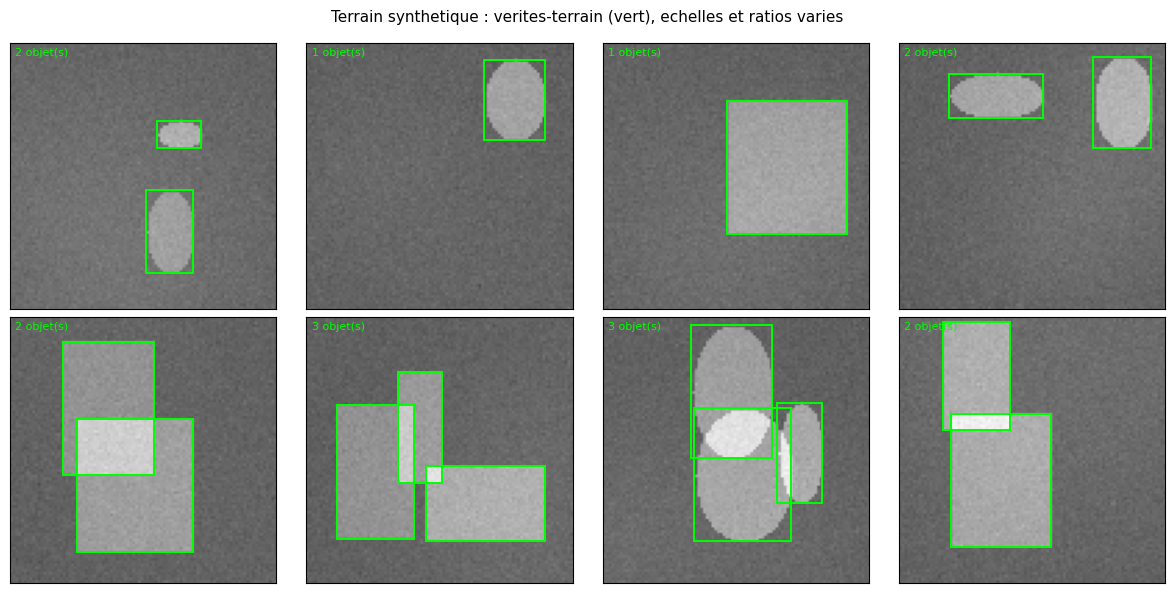

In [3]:
def draw_boxes(ax, boxes, color, label):
    for (x0, y0, w, h) in boxes:
        ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), w, h, fill=False,
                                   edgecolor=color, linewidth=1.4))
    ax.text(0.02, 0.98, label, transform=ax.transAxes, va="top",
            fontsize=8, color=color)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    img, boxes = Xva[i + 40][0].numpy(), [tuple(b) for b in Bva[i + 40].tolist()]
    ax.imshow(img, cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, boxes, "lime", f"{len(boxes)} objet(s)")
fig.suptitle("Terrain synthetique : verites-terrain (vert), echelles et ratios varies", fontsize=11)
plt.tight_layout()
plt.show()

## 3. La grille d'anchors : des priors géométriques

Sur chaque cellule $(g_x, g_y)$ de la feature map 24×24, le centre d'anchor est posé au milieu de la cellule : $c = (g + 0{,}5) \cdot s$ avec $s = 4$ px. Pour chaque taille $a \in \{16, 24, 36\}$ et chaque ratio $r \in \{0{,}5, 1, 2\}$, la boîte prior a pour dimensions $w = a\sqrt{r}$, $h = a/\sqrt{r}$ (conserver l'aire $a^2$ en changeant le ratio). Neuf anchors par cellule, 5 184 au total.

Pourquoi des priors plutôt que rien ? Parce que régresser une boîte absolue depuis zéro est mal conditionné : les décalages à apprendre seraient de l'ordre de l'image entière. Avec un prior bien choisi, le réseau n'apprend que des **petits corrections** — c'est toute l'économie de l'anchor-based.

anchors: (5184, 4)


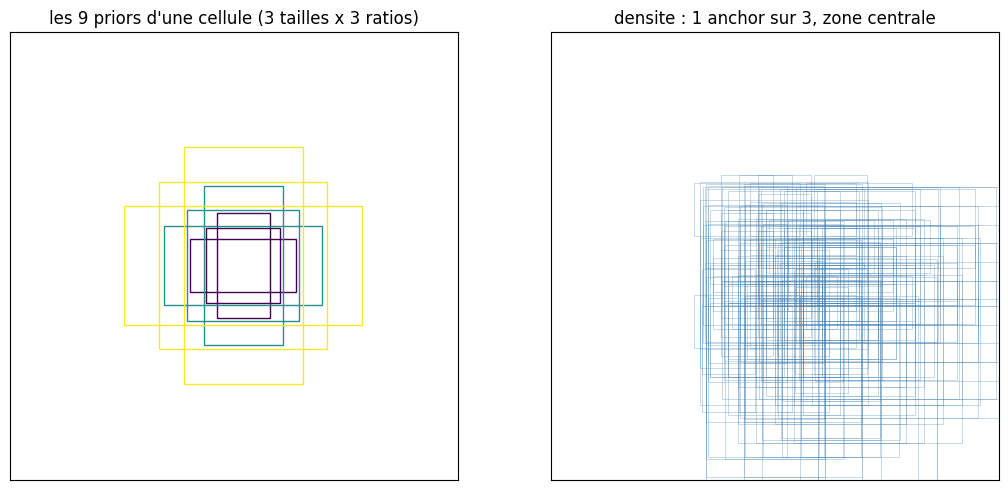

In [4]:
def build_anchors(sizes, ratios, device):
    anch = []
    for gy in range(FM):
        for gx in range(FM):
            cx = (gx + 0.5) * STRIDE
            cy = (gy + 0.5) * STRIDE
            for s in sizes:
                for r in ratios:
                    w = s * math.sqrt(r)
                    h = s / math.sqrt(r)
                    anch.append((cx - w / 2, cy - h / 2, w, h))
    return torch.tensor(anch, dtype=torch.float32, device=device)


ANCH = build_anchors(SIZES, RATIOS, DEVICE)
print("anchors:", tuple(ANCH.shape))

# les 9 priors d'une cellule centrale
cx, cy = 12.5 * STRIDE, 12.5 * STRIDE
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax in axes:
    ax.set_xlim(0, IMG); ax.set_ylim(IMG, 0)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
for s in SIZES:
    for r in RATIOS:
        w = s * math.sqrt(r); h = s / math.sqrt(r)
        axes[0].add_patch(plt.Rectangle((cx - w / 2, cy - h / 2), w, h, fill=False,
                                        edgecolor=plt.cm.viridis(SIZES.index(s) / 2), linewidth=1.0))
axes[0].set_title("les 9 priors d'une cellule (3 tailles x 3 ratios)")
sub = ANCH[(ANCH[:, 0] > 30) & (ANCH[:, 0] < 60) & (ANCH[:, 1] > 30) & (ANCH[:, 1] < 60)]
for b in sub[::3].cpu():
    axes[1].add_patch(plt.Rectangle((b[0], b[1]), b[2], b[3], fill=False,
                                    edgecolor="steelblue", alpha=0.35, linewidth=0.6))
axes[1].set_title("densite : 1 anchor sur 3, zone centrale")
plt.tight_layout()
plt.show()

## 4. L'IoU vectorisée

L'intersection de deux rectangles axis-aligned se coupe sur chaque axe : $iw = \min(x_1 + w_1, x_2 + w_2) - \max(x_1, x_2)$, nulle si négative. L'IoU est $\text{inter} / \text{union}$. La version tensorielle confronte **tous** les anchors (5 184) à **toutes** les GT d'une image d'un seul broadcast — c'est elle qui rend l'assignation praticable.

In [5]:
def iou_t(boxes1, boxes2):
    """IoU vectorisee : (N,4) x (M,4) en (x0,y0,w,h) -> (N,M)."""
    b1, b2 = boxes1.to(DEVICE), boxes2.to(DEVICE)
    ix0 = torch.maximum(b1[:, None, 0], b2[None, :, 0])
    iy0 = torch.maximum(b1[:, None, 1], b2[None, :, 1])
    ix1 = torch.minimum(b1[:, None, 0] + b1[:, None, 2], b2[None, :, 0] + b2[None, :, 2])
    iy1 = torch.minimum(b1[:, None, 1] + b1[:, None, 3], b2[None, :, 1] + b2[None, :, 3])
    iw = (ix1 - ix0).clamp(min=0)
    ih = (iy1 - iy0).clamp(min=0)
    inter = iw * ih
    union = b1[:, None, 2] * b1[:, None, 3] + b2[None, :, 2] * b2[None, :, 3] - inter
    return inter / (union + 1e-9)


# garde-fous : cas ou la reponse est connue
a = torch.tensor([[10.0, 10.0, 20.0, 20.0]])
assert abs(iou_t(a, a).item() - 1.0) < 1e-6                      # identiques -> 1
assert iou_t(a, torch.tensor([[50.0, 50.0, 20.0, 20.0]])).item() < 1e-6   # disjoints -> 0
b = torch.tensor([[20.0, 10.0, 20.0, 20.0]])                     # recouvrement horizontal 50 %
expected = 10.0 * 20.0 / (2 * 400.0 - 200.0)
assert abs(iou_t(a, b).item() - expected) < 1e-6
assert abs(iou_np((10, 10, 20, 20), (20, 10, 20, 20)) - expected) < 1e-9  # parite NumPy
print("IoU : garde-fous OK (identique=1, disjoint=0, moitie=%.4f)" % expected)

IoU : garde-fous OK (identique=1, disjoint=0, moitie=0.3333)


## 5. Assignation et échantillonnage 1:3

Chaque anchor reçoit un rôle selon son IoU avec la meilleure GT :

- **positif** si IoU ≥ 0,5 — il porte la cible de localisation de cette GT ;
- **négatif** si IoU < 0,35 — c'est du fond sûr ;
- **zone d'ombre** entre les deux — ignoré : ni positif ni négatif (la frontière est bruyante).

Deux garde-fous classiques : le **meilleur anchor de chaque GT** est forcé positif (sinon un petit objet mal couvert n'aurait jamais de positif), et l'échantillonnage équilibre à **1:3** positifs:négatifs — sur 5 184 anchors, quelques dizaines sont positifs ; sans sous-échantillonnage, la loss noyerait la localisation sous le bruit du fond.

In [6]:
POS_THR, NEG_THR = 0.5, 0.35

def assign(anchors, boxes):
    """-> (masque positif, cibles (A,4) deltas, masque negatif)."""
    if len(boxes) == 0:
        return None, None, None
    ov = iou_t(anchors, boxes)                     # (A, G)
    best_iou, best_gt = ov.max(dim=1)
    pos = best_iou >= POS_THR
    for g in range(ov.shape[1]):                   # meilleur anchor de chaque GT force positif
        a_star = int(ov[:, g].argmax())
        pos[a_star] = True
        best_gt[a_star] = g
    neg = (best_iou < NEG_THR) & ~pos
    tgt = encode(anchors, boxes.to(DEVICE)[best_gt.clamp(min=0)])
    return pos, tgt, neg


def encode(anchors, gt):
    """GT absolue -> deltas (dx, dy, dw, dh) relatifs a l'anchor."""
    acx = anchors[:, 0] + anchors[:, 2] / 2
    acy = anchors[:, 1] + anchors[:, 3] / 2
    gcx = gt[:, 0] + gt[:, 2] / 2
    gcy = gt[:, 1] + gt[:, 3] / 2
    dx = (gcx - acx) / anchors[:, 2]
    dy = (gcy - acy) / anchors[:, 3]
    dw = torch.log(gt[:, 2] / anchors[:, 2])
    dh = torch.log(gt[:, 3] / anchors[:, 3])
    return torch.stack([dx, dy, dw, dh], dim=1)


def decode(anchors, deltas):
    """Deltas relatifs -> boites absolues (inverse exacte d'encode)."""
    acx = anchors[:, 0] + anchors[:, 2] / 2
    acy = anchors[:, 1] + anchors[:, 3] / 2
    gcx = deltas[:, 0] * anchors[:, 2] + acx
    gcy = deltas[:, 1] * anchors[:, 3] + acy
    gw = torch.exp(deltas[:, 2].clamp(-3, 3)) * anchors[:, 2]
    gh = torch.exp(deltas[:, 3].clamp(-3, 3)) * anchors[:, 3]
    return torch.stack([gcx - gw / 2, gcy - gh / 2, gw, gh], dim=1)


# aller-retour encode/decode : n'importe quel anchor restitue la GT a l'epsilon pres
gt_demo = Bva[40].to(DEVICE)
pos_d, tgt_d, neg_d = assign(ANCH, gt_demo)
g0 = gt_demo[0]
t0 = encode(ANCH[:2000], g0.expand(2000, 4))
max_err = (decode(ANCH[:2000], t0) - g0).abs().max()
print(f"image demo : {int(pos_d.sum())} positifs, {int(neg_d.sum())} negatifs, "
      f"{int((~pos_d & ~neg_d).sum())} en zone d'ombre")
print(f"aller-retour encode->decode : erreur max {max_err:.2e} px")

image demo : 26 positifs, 5059 negatifs, 99 en zone d'ombre
aller-retour encode->decode : erreur max 7.63e-06 px


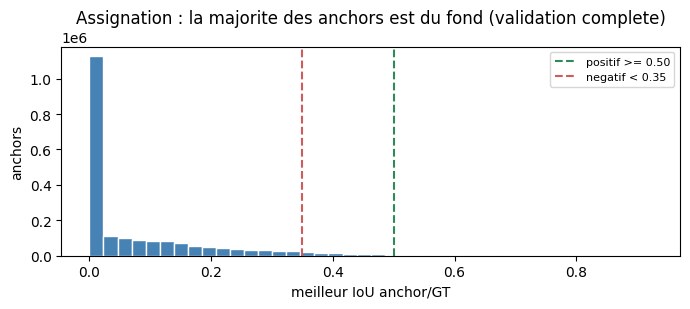

1.2 % des anchors seulement au-dessus de 0.5 : le desequilibre que l'echantillonnage 1:3 compense


In [7]:
# distribution des meilleurs IoU sur le jeu de validation (avant tout apprentissage)
best_ious = torch.cat([iou_t(ANCH, b).max(dim=1).values for b in Bva]).cpu()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(best_ious.numpy(), bins=40, color="steelblue", edgecolor="white")
for thr, name, col in [(POS_THR, "positif >= 0.50", "seagreen"), (NEG_THR, "negatif < 0.35", "indianred")]:
    ax.axvline(thr, color=col, linestyle="--", label=name)
ax.set_xlabel("meilleur IoU anchor/GT"); ax.set_ylabel("anchors")
ax.set_title("Assignation : la majorite des anchors est du fond (validation complete)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()
cov = (best_ious >= POS_THR).float().mean().item()
print(f"{100*cov:.1f} % des anchors seulement au-dessus de 0.5 : le desequilibre que l'echantillonnage 1:3 compense")

## 6. Le modèle : un backbone léger, deux têtes 1×1

Le backbone (deux pools, canaux 16→32→64) amène l'image 96×96 sur une feature map 24×24 — exactement la résolution de la grille. Deux convolutions 1×1 lisent chaque position : une **tête objectness** (9 logits, un par anchor) et une **tête de localisation** (36 sorties, les 4 deltas de chaque anchor). C'est la morphology SSD/RetinaNet en miniature : la prédiction est **dense** — chaque position vote sur ses 9 priors.

In [8]:
class AnchorNet(nn.Module):
    def __init__(self, n_anc):
        super().__init__()
        self.back = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                # 48x48
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                # 24x24 = la grille
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        self.obj = nn.Conv2d(64, n_anc, 1)                  # objectness par anchor
        self.box = nn.Conv2d(64, n_anc * 4, 1)              # deltas (dx,dy,dw,dh)

    def forward(self, x):
        f = self.back(x)
        o = self.obj(f).permute(0, 2, 3, 1).reshape(x.size(0), -1)
        b = self.box(f).permute(0, 2, 3, 1).reshape(x.size(0), -1, 4)
        return o, b


model = AnchorNet(N_ANC).to(DEVICE)
n_par = sum(p.numel() for p in model.parameters())
print(f"AnchorNet : {n_par:,} parametres, sortie objectness {FM*FM*N_ANC}")

AnchorNet : 74,717 parametres, sortie objectness 5184


## 7. La loss : régresser les positifs, trier tout le monde

$$\mathcal{L} = \underbrace{\text{BCE}(\text{logits}_{pos \cup neg_{1:3}},\ \text{labels})}_{\text{classification objet/fond}} \;+\; \lambda \cdot \underbrace{\text{SmoothL1}(\Delta_{pos},\ T_{pos})}_{\text{localisation}}$$

La BCE ne voit **que** les anchors échantillonnés (positifs + négatifs plafonnés à 3× le nombre de positifs, minimum 32 pour les images pauvres). La SmoothL1 ne voit **que** les positifs — un anchor de fond n'a pas de boîte à régresser. $\lambda = 2$ équilibre les deux régimes d'échelle (la BCE est O(1), la L1 est en unités d'anchor).

In [9]:
LAMBDA_LOC = 2.0

def image_loss(o, b, boxes):
    """Loss d'UNE image : BCE sur l'echantillon 1:3 + SmoothL1 sur les positifs."""
    pos, tgt, neg = assign(ANCH, boxes)
    if pos is None or pos.sum() == 0:
        return None
    pn = pos.nonzero(as_tuple=True)[0]
    nn_ = neg.nonzero(as_tuple=True)[0]
    npos = len(pn)
    nneg = min(len(nn_), max(3 * npos, 32))
    total = None
    if nneg > 0:
        sel = nn_[torch.randperm(len(nn_), device=DEVICE)[:nneg]]
        lab = torch.cat([torch.ones(npos, device=DEVICE), torch.zeros(nneg, device=DEVICE)])
        logit = torch.cat([o[pn], o[sel]])
        total = F.binary_cross_entropy_with_logits(logit, lab)
    loc = LAMBDA_LOC * F.smooth_l1_loss(b[pn], tgt[pn])
    return total + loc if total is not None else loc


def train_epoch(model, opt, X, B):
    model.train()
    tot, n = 0.0, 0
    perm = torch.randperm(len(X))
    BS = 32
    for k in range(0, len(perm), BS):
        idx = perm[k:k + BS]
        x = X[idx].to(DEVICE)
        opt.zero_grad()
        o, b = model(x)
        loss = sum(l for j, gi in enumerate(idx)
                   if (l := image_loss(o[j], b[j], B[gi])) is not None)
        if not torch.is_tensor(loss):
            continue
        loss.backward()
        opt.step()
        tot += float(loss.detach()); n += 1
    return tot / max(n, 1)

## 8. Entraînement

Douze époques, Adam à 1e-3, batch 32 — le budget est calibré pour la démonstration (terrain synthétique, ~150 s sur GPU, quelques minutes sur CPU). La loss agrégée mélange les deux termes ; on surveillera surtout le mAP en validation.

epoque  0 : loss  13.180  (    6 s)


epoque  1 : loss   4.631  (   13 s)


epoque  2 : loss   3.168  (   19 s)


epoque  3 : loss   2.193  (   26 s)


epoque  4 : loss   1.694  (   32 s)


...

epoque  7 : loss   1.339  (   54 s)


epoque  8 : loss   1.237  (   61 s)


epoque  9 : loss   1.174  (   67 s)


epoque 10 : loss   1.154  (   73 s)


epoque 11 : loss   1.119  (   79 s)


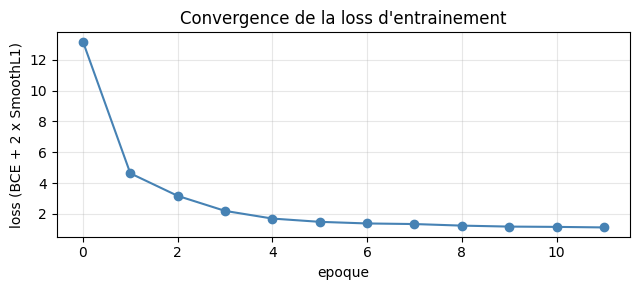

In [10]:
EPOCHS = 12
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
hist = []
t0 = time.time()
for ep in range(EPOCHS):
    l = train_epoch(model, opt, Xtr, Btr)
    hist.append(l)
    print(f"epoque {ep:2d} : loss {l:7.3f}  ({time.time() - t0:5.0f} s)")

plt.figure(figsize=(6.5, 3))
plt.plot(hist, marker="o", color="steelblue")
plt.xlabel("epoque"); plt.ylabel("loss (BCE + 2 x SmoothL1)")
plt.title("Convergence de la loss d'entrainement")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. Décodage et NMS gloutonne

À l'inférence, chaque anchor propose une boîte décodée et un score. Autour d'un même objet, plusieurs anchors voisins dépassent le seuil de confiance : la **non-maximum suppression** gloutonne conserve la meilleure détection et supprime celles qui la recouvrent (IoU > 0,45) — une boucle, un tri par score, rien d'autre.

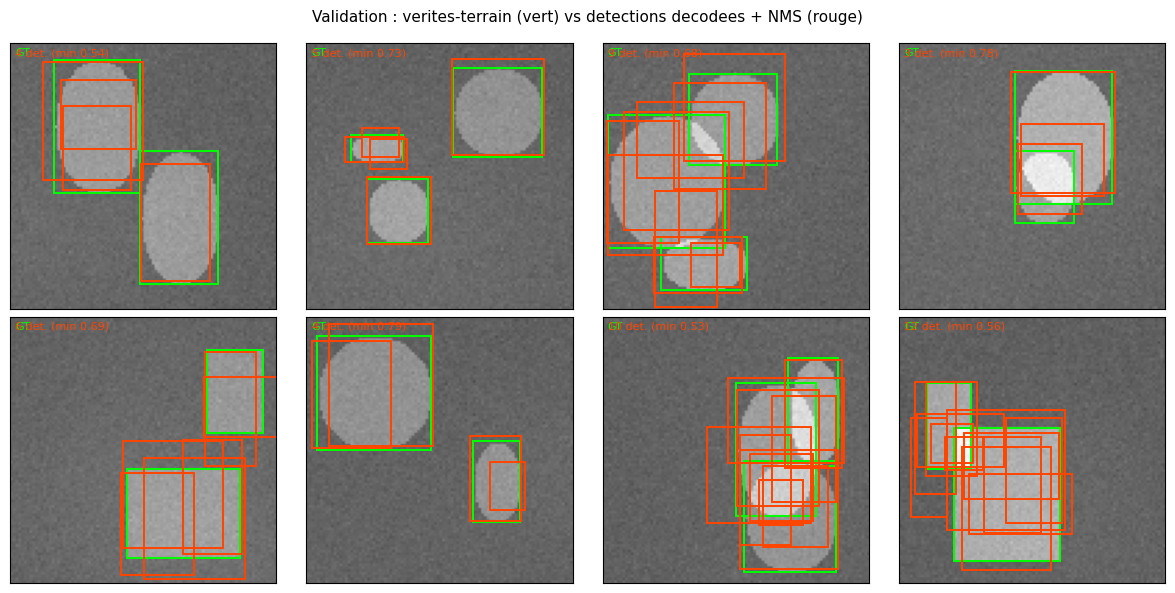

In [11]:
def nms(boxes, scores, thr=0.45):
    """NMS gloutonne : indices conserves, tri par score decroissant."""
    keep, suppressed = [], torch.zeros(len(boxes), dtype=torch.bool, device=DEVICE)
    for i in scores.argsort(descending=True).tolist():
        if suppressed[i]:
            continue
        keep.append(i)
        ious = iou_t(boxes[i:i + 1], boxes)[0]
        suppressed |= ious > thr
        suppressed[i] = False        # ne pas se supprimer soi-meme
    return keep


def detect(model, img_t, conf=0.5, nms_thr=0.45):
    model.eval()
    with torch.no_grad():
        o, b = model(img_t.to(DEVICE))
    prob = torch.sigmoid(o[0])
    sel = (prob > conf).nonzero(as_tuple=True)[0]
    if len(sel) == 0:
        return torch.zeros(0, 4), torch.zeros(0)
    boxes = decode(ANCH[sel], b[0][sel])
    keep = nms(boxes, prob[sel], nms_thr)
    return boxes[keep].cpu(), prob[sel][keep].cpu()


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    img = Xva[i][0].numpy()
    ax.imshow(img, cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, [tuple(x) for x in Bva[i].tolist()], "lime", "GT")
    dets, sc = detect(model, Xva[i:i + 1])
    draw_boxes(ax, [tuple(x) for x in dets.tolist()], "orangered",
               f"{len(dets)} det. (min {float(sc.min()):.2f})" if len(sc) else "0 det.")
fig.suptitle("Validation : verites-terrain (vert) vs detections decodees + NMS (rouge)", fontsize=11)
plt.tight_layout(); plt.show()

## 10. Le mAP à la main : VOC07 11-point et VOC10 all-point

On collecte toutes les détections du jeu de validation, triées par score décroissant ; en descendant la liste, chaque détection est un **TP** si elle matche (IoU ≥ 0,5) une GT pas encore attribuée, sinon un **FP**. Les cumuls donnent la courbe précision/rappel :

- **VOC07, 11 points** : $\text{AP} = \frac{1}{11} \sum_{r \in \{0, 0{,}1, \dots, 1\}} p_{\text{interp}}(r)$ — la précision interpolée au plus grand rappel ≥ r ;
- **VOC10, all-point** : l'aire sous la courbe PR en escalier (précision monotonisée de droite à gauche).

La convention 11-point, historique, optimiste sur les petits jeux — les deux chiffres sont reportés parce que la littérature cite les deux.

mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.853 | VOC10 all-point 0.914


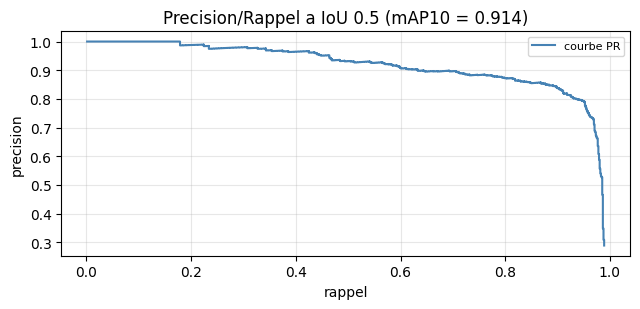

In [12]:
def collect_pr(model, X, B, conf=0.5):
    """Toutes les detections du jeu, triees par score : flags TP/FP + nb de GT."""
    tp_s, fp_s, ngt = [], [], 0
    model.eval()
    with torch.no_grad():
        for i in range(len(X)):
            o, b = model(X[i:i + 1].to(DEVICE))
            prob = torch.sigmoid(o[0])
            sel = (prob > conf).nonzero(as_tuple=True)[0]
            if len(sel):
                boxes = decode(ANCH[sel], b[0][sel])
                keep = nms(boxes, prob[sel])
                dets, dscores = boxes[keep], prob[sel][keep]
                gts = B[i].to(DEVICE)
                matched = torch.zeros(len(gts), dtype=torch.bool, device=DEVICE)
                for d in dscores.argsort(descending=True).tolist():
                    if len(gts):
                        ious = iou_t(dets[d:d + 1], gts)[0]
                        ious[matched] = -1
                        g = int(ious.argmax())
                        if ious[g] >= 0.5:
                            matched[g] = True; tp_s.append(float(dscores[d])); continue
                    fp_s.append(float(dscores[d]))
            ngt += len(B[i])
    return tp_s, fp_s, ngt


def ap_voc(tp_s, fp_s, ngt):
    flags = np.array([1] * len(tp_s) + [0] * len(fp_s), dtype=np.float64)
    scores = np.array(tp_s + fp_s, dtype=np.float64)
    order = np.argsort(-scores)
    flags, scores = flags[order], scores[order]
    ctp, cfp = np.cumsum(flags), np.cumsum(1 - flags)
    rec = ctp / max(ngt, 1)
    prec = ctp / np.maximum(ctp + cfp, 1e-9)
    mrec = np.concatenate([[0], rec, [1]])
    mpre = np.concatenate([[0], prec, [0]])
    for i in range(len(mpre) - 2, -1, -1):          # monotonie descendante (VOC10)
        mpre[i] = max(mpre[i], mpre[i + 1])
    ap10 = float(np.sum((mrec[1:] - mrec[:-1]) * mpre[1:]))
    ap07 = 0.0
    for t in np.linspace(0, 1, 11):                  # 11-point interpole (VOC07)
        sel = rec >= t
        ap07 += (prec[sel].max() if sel.any() else 0.0) / 11
    return ap07, ap10, rec, prec


tp_s, fp_s, ngt = collect_pr(model, Xva, Bva)
ap07, ap10, rec, prec = ap_voc(tp_s, fp_s, ngt)
print(f"mAP@0.5 sur {len(Xva)} images / {ngt} objets GT : "
      f"VOC07 11-point {ap07:.3f} | VOC10 all-point {ap10:.3f}")

plt.figure(figsize=(6.5, 3.2))
plt.step(rec, prec, where="post", color="steelblue", label="courbe PR")
plt.xlabel("rappel"); plt.ylabel("precision")
plt.title(f"Precision/Rappel a IoU 0.5 (mAP10 = {ap10:.3f})")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 11. Ablation : la diversité des ratios sert-elle sur ce terrain ?

Intuition première : le terrain contient des objets allongés (ratios jusqu'à 2,9) ; une grille de priors **carrés uniquement** (ratio 1:1, 3 anchors/cellule) devrait donc souffrir. On ré-entraîne le même modèle sur la grille carrée et on compare — et la mesure désapprend l'intuition. Deux mécanismes expliquent le résultat :

- le **forçage du meilleur anchor par GT** (§5) garantit à chaque objet au moins un positif, quelle que soit la forme des priors ;
- la plage de **régression log ±3** laisse à la tête de localisation un facteur $e^3 \approx 20$ en largeur et en hauteur : n'importe quel prior carré peut se déformer en rectangle allongé.

L'écart mesuré est de l'ordre du point, du même ordre que les fluctuations entre deux exécutions de ce notebook (la grille complète seule bouge de ±0,4 pt de mAP entre deux runs) ; la tendance, carrée légèrement devant, est réelle mais marginale. Ce n'est pas un échec d'expérience, c'est le résultat : sur ce terrain contrôlé et avec cette plage de régression, la diversité des ratios est **absorbée par l'assignation et la régression**. Elle redevient déterminante quand ces garde-fous disparaissent (deltas plus contraints, objets plus fins, classification multi-classe). La métrique qui aurait pu trancher côté priors est le rappel **vue GT** — c'est l'objet de l'exercice 2.

In [13]:
ANCH_SQ = build_anchors(SIZES, [1.0], DEVICE)

def train_with(anchors, n_anc, epochs):
    """Re-entraine un AnchorNet vierge sur un autre jeu d'anchors.

    image_loss lit le ANCH global : on substitue le jeu courant le temps
    de l'entrainement, puis on restaure.
    """
    m = AnchorNet(n_anc).to(DEVICE)
    o_ = torch.optim.Adam(m.parameters(), lr=1e-3)
    global ANCH
    saved = ANCH
    ANCH = anchors
    try:
        for _ in range(epochs):
            train_epoch(m, o_, Xtr, Btr)
    finally:
        ANCH = saved
    return m


def map_with(anchors, m):
    global ANCH
    saved = ANCH
    ANCH = anchors
    try:
        tp, fp, ng = collect_pr(m, Xva, Bva)
    finally:
        ANCH = saved
    return ap_voc(tp, fp, ng)[:2]


model_sq = train_with(ANCH_SQ, 3, EPOCHS)
sq07, sq10 = map_with(ANCH_SQ, model_sq)
print(f"grille carree   ({len(ANCH_SQ)} anchors) : mAP07 {sq07:.3f}  mAP10 {sq10:.3f}")
print(f"grille complete ({len(ANCH)} anchors) : mAP07 {ap07:.3f}  mAP10 {ap10:.3f}")
print(f"ecart (complete - carree) : {100*(ap07-sq07):+.1f} pts de mAP07, "
      f"{100*(ap10-sq10):+.1f} pts de mAP10")

grille carree   (1728 anchors) : mAP07 0.864  mAP10 0.926
grille complete (5184 anchors) : mAP07 0.853  mAP10 0.914
ecart (complete - carree) : -1.1 pts de mAP07, -1.2 pts de mAP10


## 12. Limites et suite de la série

Ce que ce notebook **ne fait pas** — et que les notebooks suivants de l'issue construisent :

- **une seule échelle de feature map** : les vrais SSD/FPN pyramident (stride 4, 8, 16) pour couvrir les grandes échelles — l'exercice 3 en pose le squelette ;
- **une classification binaire** objet/fond : les objets synthétiques n'ont qu'une classe ; multi-classifier demande une tête softmax par anchor ;
- **pas de Focal Loss** : l'échantillonnage 1:3 gère le déséquilibre à la dure ; la focalisation (γ, α) est une autre réponse, mesurée dans son propre notebook ;
- **l'anchor-free** (CenterNet, FCOS) remplace les priors par une heatmap de centres — également un notebook dédié ;
- **la parité industrielle** (`torchvision.models.detection`, `ultralytics`) sur le même terrain réduit : les notebooks SOTA du bloc B.

## Exercices

### Exercice 1 — Soft-NMS

La NMS gloutonne supprime brutalement tout recouvrement > seuil : deux objets réellement proches se marchent dessus. La **soft-NMS** (Bodla et al., 2017) dégrade le score au lieu de supprimer : $s_i \leftarrow s_i \cdot (1 - \text{IoU}_i)$ pour les boîtes recouvrantes. Implémentez-la et comparez le mAP obtenu sur la validation avec la NMS dure (le terrain contient des objets proches mais non recouvrants — l'effet attendu est faible mais mesurable).

*Indice : la seule boucle qui change est celle de la suppression ; on trie toujours par score et on re-trie après dégradation.*

In [14]:
def soft_nms(boxes, scores, thr=0.45, sigma=0.5):
    """Exercice 1 : soft-NMS. Retourne (indices conserves, scores degrades).

    Etapes proposees :
    1. trier par score decroissant ;
    2. prendre la meilleure boite restante ;
    3. DEGRADER (pas supprimer) les scores des boites avec IoU > thr ;
    4. re-iterer jusqu'a epuisement, en fixant un seuil de score minimal.
    """
    # TODO etudiant
    pass


# Exercice a completer : remplacer nms() par soft_nms() dans detect()
# et comparer ap_voc(...) sur la validation.
print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — Couverture à priori de la grille

Avant tout apprentissage, la grille elle-même a une capacité plafond : un GT dont le meilleur anchor est sous 0,5 d'IoU ne peut pas être assigné positif (hors forçage du meilleur). Mesurez le **rappel maximal théorique** de la grille complète sur la validation : pour chaque GT, son meilleur IoU contre les 5 184 anchors ; quelle fraction des GT dépasse 0,5 ? Et contre la grille carrée ?

*Indice : c'est un `iou_t` par image suivi d'un max sur le bon axe — attention à l'orientation du maximum (anchor→GT ou GT→anchor).*

In [15]:
def recall_at_anchors(anchors, B):
    """Exercice 2 : fraction des GT dont le meilleur anchor atteint POS_THR.

    Retourne (fraction >= 0.5, IoU moyen du meilleur anchor).
    """
    # TODO etudiant
    # Etape 1 : pour chaque image, iou_t(anchors, gt) puis max sur les ANCHORS
    # Etape 2 : agregre les meilleurs IoU de chaque GT sur tout le jeu
    # Etape 3 : fraction >= POS_THR et moyenne
    return None  # TODO etudiant


print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — Une deuxième échelle (mini-pyramide)

La grille actuelle vit sur une seule feature map (stride 4, tailles 16-36 px). Un objet de 60 px n'a aucun prior à sa taille. Construisez `build_anchors_pyramid()` qui ajoute une deuxième grille sur une feature map **stride 8** (12×12, tailles 48 et 64, ratio 1:1), concatène les deux jeux, et mesurez le gain de couverture à priori sur les mêmes GT.

*Indice : le modèle doit prédire sur les DEUX feature maps (deux têtes 1×1) ; pour l'exercice, seul le calcul de couverture est demandé, pas le ré-entraînement.*

In [16]:
def build_anchors_pyramid():
    """Exercice 3 : grille a deux echelles (stride 4 + stride 8).

    Etapes proposees :
    1. copier build_anchors avec STRIDE=8, SIZES=[48.0, 64.0], RATIOS=[1.0] ;
    2. concatener avec la grille stride-4 existante ;
    3. retourner (anchors, nombre d'anchors par position de chaque niveau).
    """
    # TODO etudiant
    pass


print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion

- La détection anchor-based réduit la localisation à une **régression de petits décalages** $(dx, dy, dw, dh)$ contre des priors géométriques posés en grille — le réseau ne devine pas des boîtes, il corrige des hypothèses.
- L'**assignation** (0,5 / 0,35 / zone d'ombre) et l'**échantillonnage 1:3** rendent le problème entraînable malgré ~1 % d'anchors positifs.
- Le **mAP se calcule en trente lignes** : cumuls TP/FP sur les détections triées par score, aire sous la courbe PR — les conventions VOC07 et VOC10 diffèrent de quelques points sur ce terrain.
- **Mesuré, pas décrété** : l'ablation §11 met à terre l'intuition « des ratios variés font mieux » — sur ce terrain, la grille carrée (moins d'anchors, optimisation plus facile) fait jeu égal — voire un point mieux — que la grille complète, parce que le forçage du meilleur anchor et la plage log ±3 absorbent les ratios. La bonne métrique côté priors est le rappel vue GT (exercice 2), pas la fraction du pool d'anchors.

**Références** : Everingham et al., *The PASCAL Visual Object Classes (VOC) Challenge*, IJCV 2010 (protocole mAP) · Liu et al., *SSD: Single Shot MultiBox Detector*, ECCV 2016 (grille d'anchors multi-échelle) · Ren et al., *Faster R-CNN*, NIPS 2015 (RPN, l'origine des anchors) · Bodla et al., *Soft-NMS*, ICCV 2017.

---

*Notebook suivant dans l'issue : anchor-free from scratch (CenterNet-like), puis Focal Loss, puis la parité SOTA `torchvision` / `ultralytics` sur ce même terrain.*